# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The dataset was prepared from NYC Open Data's [*311 Service Requests from 2020 to Present*](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9). It contains 70,198 requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded, and the four features below were retained. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The dataset has no missing values in the retained features and was downloaded on August 13, 2026. Request counts may reflect borough population, street mileage, construction activity, awareness of 311, access to the service, and willingness to report. Therefore, borough comparisons describe **reported request volume**; they do not directly measure street quality or government performance.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [22]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [23]:
# Write your code here.
requests = pd.read_csv(
    "data/nyc_311_street_conditions_2025.csv",
    parse_dates=["created_date"]
)

### Preview the data

Display the first and last five rows.


In [24]:
# Write your code here.
display(requests.head())
display(requests.tail())

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [25]:
# Write your code here.
display(requests.dtypes)
display(requests.isna().sum())

request_id               int64
created_date    datetime64[ns]
borough                 object
descriptor              object
dtype: object

request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | Categorical | `int64` | 0 |
| `created_date` | Temporal | `datetime64[ns]` | 0 |
| `borough` | Categorical | `object` | 0 |
| `descriptor` | Categorical | `object` | 0 |


**What does one row represent?**

Your answer: Each row represents one street-condition service request reported to NYC 311.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Brooklyn will have the greatest typical number of daily requests because it is a large borough with many residents and streets.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [26]:
# Write your code here.
requests["borough"] = requests["borough"].str.title()

**What roles do `.str` and `.title()` play in this statement?**

Your answer:
.str gives access to string methods for the column, and .title() converts each borough name to title case.

### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [27]:
# Write your code here.
requests["date"] = requests["created_date"].dt.normalize()

### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [28]:
# Write your code here.
daily_requests = (
    requests.groupby(["date", "borough"])
    .size()
    .reset_index(name="request_count")
)

daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of daily_requests represents the total number of requests for one borough on one date. In requests, each row represents one individual service request.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: We removed the time so that all requests from the same calendar date would be grouped together. If we kept the time, requests made at different times would be treated as separate groups.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [29]:
# Write your code here.
borough_order = [
    "Bronx",
    "Brooklyn",
    "Manhattan",
    "Queens",
    "Staten Island"
]

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [30]:
# Write your code here.
borough_summary = (
    daily_requests.groupby("borough")["request_count"]
    .mean()
    .reindex(borough_order)
)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: Comparing only the means is incomplete because they do not show how much the daily request counts vary or how the distributions are shaped.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [31]:
# Write your code here.
daily_requests.groupby("borough").size().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes. Every borough has a request count for all 365 dates.


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It would mean that the borough had no recorded requests on at least one date.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [32]:
# Write your code here.
display(daily_requests[["date", "borough", "request_count"]].isna().sum())

display(
    daily_requests.groupby("borough")["request_count"]
    .describe()
    .reindex(borough_order)
)

date             0
borough          0
request_count    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No. There are no missing values, and all of the request counts are positive and reasonable.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer:
No. A zero could be possible if a borough had no reported requests on a particular day.

## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


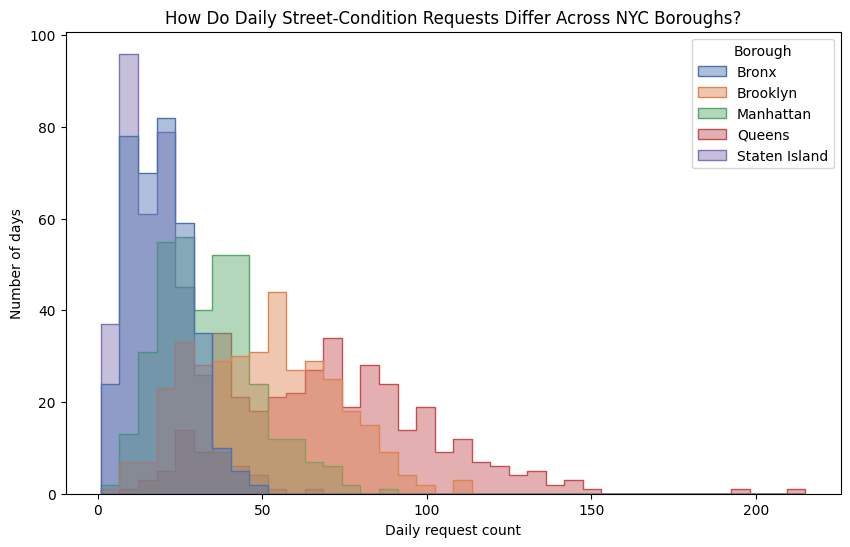

In [33]:
# Write your code here.
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=daily_requests,
    x="request_count",
    hue="borough",
    hue_order=borough_order,
    element="step",
    multiple="layer",
    alpha=0.45,
    palette="deep"
)

ax.set_title("How Do Daily Street-Condition Requests Differ Across NYC Boroughs?")
ax.set_xlabel("Daily request count")
ax.set_ylabel("Number of days")
ax.get_legend().set_title("Borough")

plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: Queens generally has higher daily request counts and a wider spread, while the Bronx and Staten Island tend to have lower counts. The histogram shows the overall shapes well, but the overlapping distributions make some boroughs difficult to compare directly.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


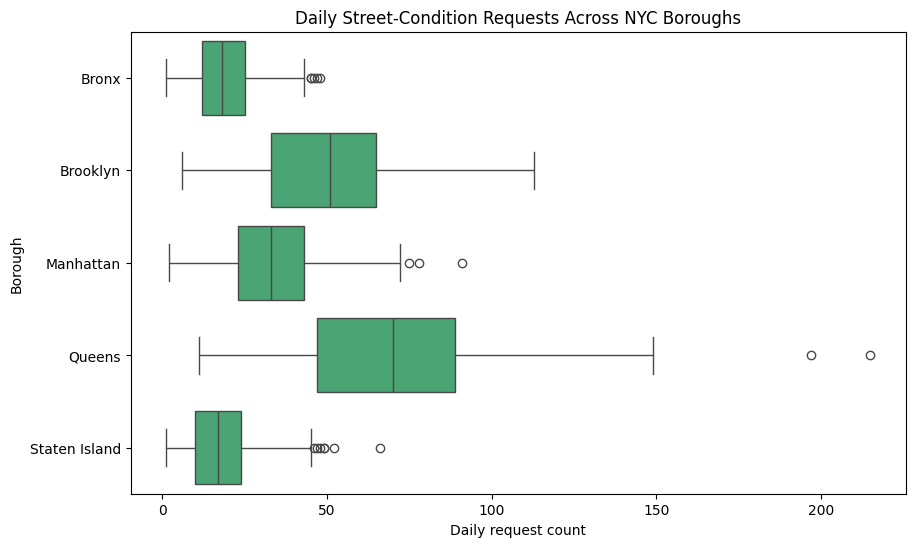

In [34]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumseagreen"
)

plt.title("Daily Street-Condition Requests Across NYC Boroughs")
plt.xlabel("Daily request count")
plt.ylabel("Borough")

plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The box plot makes it easier to compare the medians and spread of the boroughs. Queens has the highest median and a wider spread, while the Bronx and Staten Island have lower daily counts. The unusually high values are also easier to identify.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


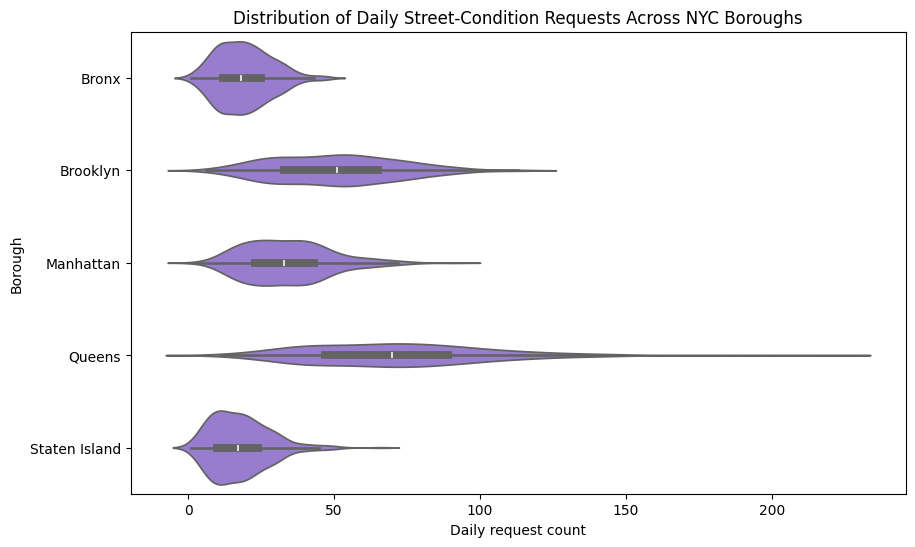

In [35]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumpurple"
)

plt.title("Distribution of Daily Street-Condition Requests Across NYC Boroughs")
plt.xlabel("Daily request count")
plt.ylabel("Borough")

plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot shows the shape and concentration of each distribution. It makes it easier to see where daily request counts are most common and how the distributions differ in spread.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: I think the box plot compares the boroughs most clearly because it makes the differences in medians, spread, and unusual values easy to see without the overlap of the histogram.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Queens had the highest typical daily request counts in 2025, followed by Brooklyn. The Bronx and Staten Island generally had the lowest daily counts, and Queens also showed greater variation across days.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: These counts measure reported requests, not the actual number of street problems. Reporting can vary because of population, awareness of 311, access to the service, and willingness to report.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How does the daily number of reported street-condition requests differ across the days of the week?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use created_date to identify the date and day of the week. Each row of my calculated DataFrame will represent the total number of street-condition requests for one calendar date.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [36]:
# Write your code here.
weekday_requests = (
    requests.groupby("date")
    .size()
    .reset_index(name="request_count")
)

weekday_requests["day_of_week"] = weekday_requests["date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_requests.head()

,date,request_count,day_of_week
0,2025-01-01,189,Wednesday
1,2025-01-02,240,Thursday
2,2025-01-03,136,Friday
3,2025-01-04,110,Saturday
4,2025-01-05,155,Sunday


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I grouped the requests by date and counted the number of requests for each day. Then I used the date to identify the day of the week, which created the groups for comparison.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [37]:
# Write your code here.
display(weekday_requests.isna().sum())

display(weekday_requests["day_of_week"].value_counts().reindex(day_order))

display(
    weekday_requests.groupby("day_of_week")["request_count"]
    .describe()
    .reindex(day_order)
)

date             0
request_count    0
day_of_week      0
dtype: int64

day_of_week
Monday       52
Tuesday      52
Wednesday    53
Thursday     52
Friday       52
Saturday     52
Sunday       52
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Monday,52.0,226.384615,58.222748,96.0,194.75,217.0,258.00,408.0
Tuesday,52.0,240.750000,53.614775,101.0,208.50,243.0,274.25,362.0
Wednesday,53.0,236.886792,57.224477,104.0,194.00,234.0,274.00,426.0
Thursday,52.0,223.115385,56.400756,40.0,192.75,216.0,265.25,330.0
Friday,52.0,183.653846,55.178457,63.0,144.00,177.5,217.25,308.0
Saturday,52.0,111.519231,28.413260,60.0,91.75,110.0,128.25,178.0
Sunday,52.0,123.096154,29.658355,57.0,104.75,124.0,146.25,186.0


**What did your checks establish?**

Your answer: The checks showed that there are no missing values and all seven days of the week are present. The request counts are positive, and the summaries show noticeable differences between weekdays and weekends.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


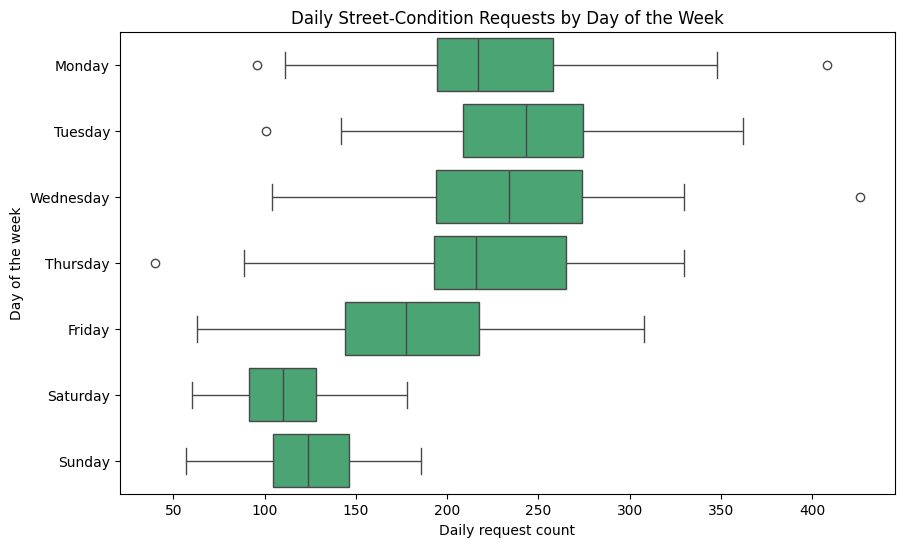

In [38]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=weekday_requests,
    x="request_count",
    y="day_of_week",
    order=day_order,
    color="mediumseagreen"
)

plt.title("Daily Street-Condition Requests by Day of the Week")
plt.xlabel("Daily request count")
plt.ylabel("Day of the week")

plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The strongest pattern is that weekday request counts are generally higher than weekend counts. Tuesday and Wednesday have some of the highest typical counts, while Saturday and Sunday are much lower.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: Daily street-condition request counts were generally higher on weekdays than on weekends in 2025. Tuesday and Wednesday had some of the highest typical daily counts, while Saturday and Sunday had the lowest.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: This analysis only uses reported 311 requests from 2025, so it does not show the actual number of street problems or explain why request counts differ by day of the week.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used ChatGPT as a tool when I noticed that the legend on my histogram was not displaying correctly. It suggested changing how I set the legend title, and I accepted the suggestion after rerunning the cell and confirming that all five borough names appeared correctly.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
